In [2]:
# Install mlxtend if it's not available in the environment (Jupyter magic)
%pip install mlxtend --quiet

import numpy as np 
import pandas as pd 
from mlxtend.plotting import plot_decision_regions

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
df = pd.DataFrame()

In [6]:
df['X1'] = [1,2,3,4,5,6,6,7,9,9]
df['X2'] = [5,3,6,8,1,9,5,8,9,2]

df['label'] = [1,1,0,1,0,1,0,1,0,0]

In [8]:
df

,X1,X2,label
0,1,5,1
1,2,3,1
2,3,6,0
3,4,8,1
4,5,1,0
5,6,9,1
6,6,5,0
7,7,8,1
8,9,9,0
9,9,2,0


<Axes: xlabel='X1', ylabel='X2'>

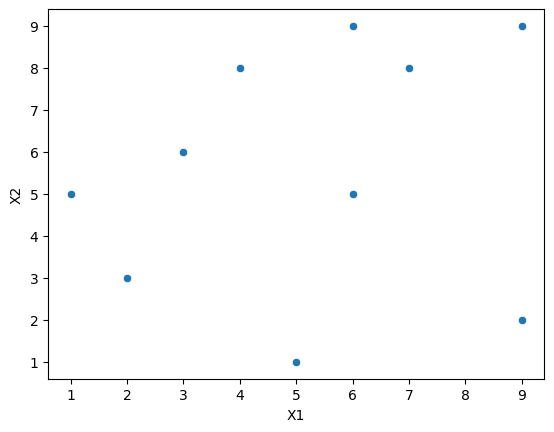

In [9]:
import seaborn as sns 
sns.scatterplot(x = df['X1'], y = df['X2'])

In [11]:
df['weights'] = 1/df.shape[0]

In [12]:
df

,X1,X2,label,weights
0,1,5,1,0.1
1,2,3,1,0.1
2,3,6,0,0.1
3,4,8,1,0.1
4,5,1,0,0.1
5,6,9,1,0.1
6,6,5,0,0.1
7,7,8,1,0.1
8,9,9,0,0.1
9,9,2,0,0.1


In [14]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=1)

In [19]:
X = df.iloc[:, 0:2].values
y = df.iloc[:,2].values

In [21]:
dt.fit(X, y)

DecisionTreeClassifier(max_depth=1)

[Text(0.5, 0.75, 'x[1] <= 2.5\ngini = 0.5\nsamples = 10\nvalue = [5, 5]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.469\nsamples = 8\nvalue = [3, 5]'),
 Text(0.625, 0.5, '  False')]

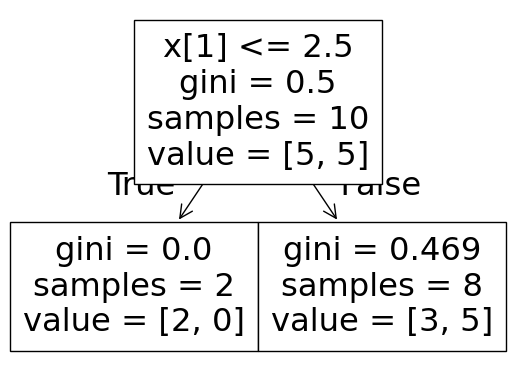

In [22]:
from sklearn.tree import plot_tree
plot_tree(dt)

<Axes: >

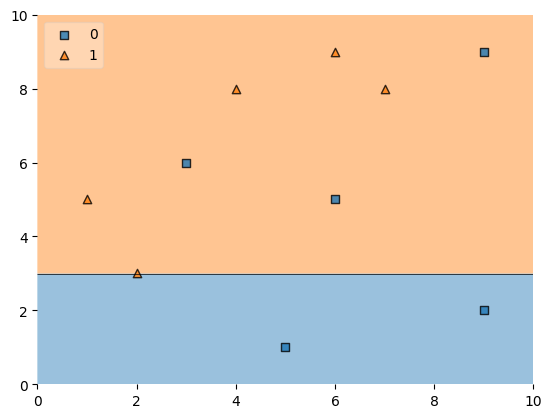

In [23]:
plot_decision_regions(X, y, clf = dt, legend = 2)

In [27]:
df['y_pred'] = dt.predict(X)
df

,X1,X2,label,weights,y_pred
0,1,5,1,0.1,1
1,2,3,1,0.1,1
2,3,6,0,0.1,1
3,4,8,1,0.1,1
4,5,1,0,0.1,0
5,6,9,1,0.1,1
6,6,5,0,0.1,1
7,7,8,1,0.1,1
8,9,9,0,0.1,1
9,9,2,0,0.1,0


In [30]:
def calculate_model_weight(error):
    return 0.5 * np.log((1-error)/(error))

In [34]:
# calculate model weight 

alpha1 = calculate_model_weight(0.3)
alpha1

np.float64(0.42364893019360184)

In [36]:
# update weights 

def update_weight(row, alpha = 0.423):
    if row['label'] == row['y_pred']:
        return row['weights'] * np.exp(-alpha)
    else:
        return row['weights'] * np.exp(alpha)



In [38]:
df['updated_weight'] = df.apply(update_weight, axis = 1)
df

,X1,X2,label,weights,y_pred,updated_weight
0,1,5,1,0.1,1,0.065508
1,2,3,1,0.1,1,0.065508
2,3,6,0,0.1,1,0.152653
3,4,8,1,0.1,1,0.065508
4,5,1,0,0.1,0,0.065508
5,6,9,1,0.1,1,0.065508
6,6,5,0,0.1,1,0.152653
7,7,8,1,0.1,1,0.065508
8,9,9,0,0.1,1,0.152653
9,9,2,0,0.1,0,0.065508


In [43]:
df['normalized weights'] = df['updated_weight']/df['updated_weight'].sum()

In [44]:
df

,X1,X2,label,weights,y_pred,updated_weight,normalized weights
0,1,5,1,0.1,1,0.065508,0.071475
1,2,3,1,0.1,1,0.065508,0.071475
2,3,6,0,0.1,1,0.152653,0.166559
3,4,8,1,0.1,1,0.065508,0.071475
4,5,1,0,0.1,0,0.065508,0.071475
5,6,9,1,0.1,1,0.065508,0.071475
6,6,5,0,0.1,1,0.152653,0.166559
7,7,8,1,0.1,1,0.065508,0.071475
8,9,9,0,0.1,1,0.152653,0.166559
9,9,2,0,0.1,0,0.065508,0.071475


In [46]:
df['cumsum upper'] = np.cumsum(df['normalized weights'])

In [49]:
df['cumsum lower'] = df['cumsum upper'] - df['normalized weights']

In [51]:
df[['X1', 'X2', 'label', 'weights', 'y_pred', 'updated_weight', 'cumsum lower', 'cumsum upper']]

,X1,X2,label,weights,y_pred,updated_weight,cumsum lower,cumsum upper
0,1,5,1,0.1,1,0.065508,0.000000,0.071475
1,2,3,1,0.1,1,0.065508,0.071475,0.142950
2,3,6,0,0.1,1,0.152653,0.142950,0.309508
3,4,8,1,0.1,1,0.065508,0.309508,0.380983
4,5,1,0,0.1,0,0.065508,0.380983,0.452458
5,6,9,1,0.1,1,0.065508,0.452458,0.523933
6,6,5,0,0.1,1,0.152653,0.523933,0.690492
7,7,8,1,0.1,1,0.065508,0.690492,0.761967
8,9,9,0,0.1,1,0.152653,0.761967,0.928525
9,9,2,0,0.1,0,0.065508,0.928525,1.000000


In [53]:
def create_datset(df):
    indices=[]
    for i in range(df.shape[0]):
        a = np.random.random()
        for index, row  in df.iterrows():
            if row['cumsum upper'] > a and a > row['cumsum lower']:
                indices.append(index)
    return indices

In [55]:
index_values = create_datset(df)

In [56]:
index_values

[1, 1, 7, 1, 6, 8, 8, 0, 0, 3]